<center>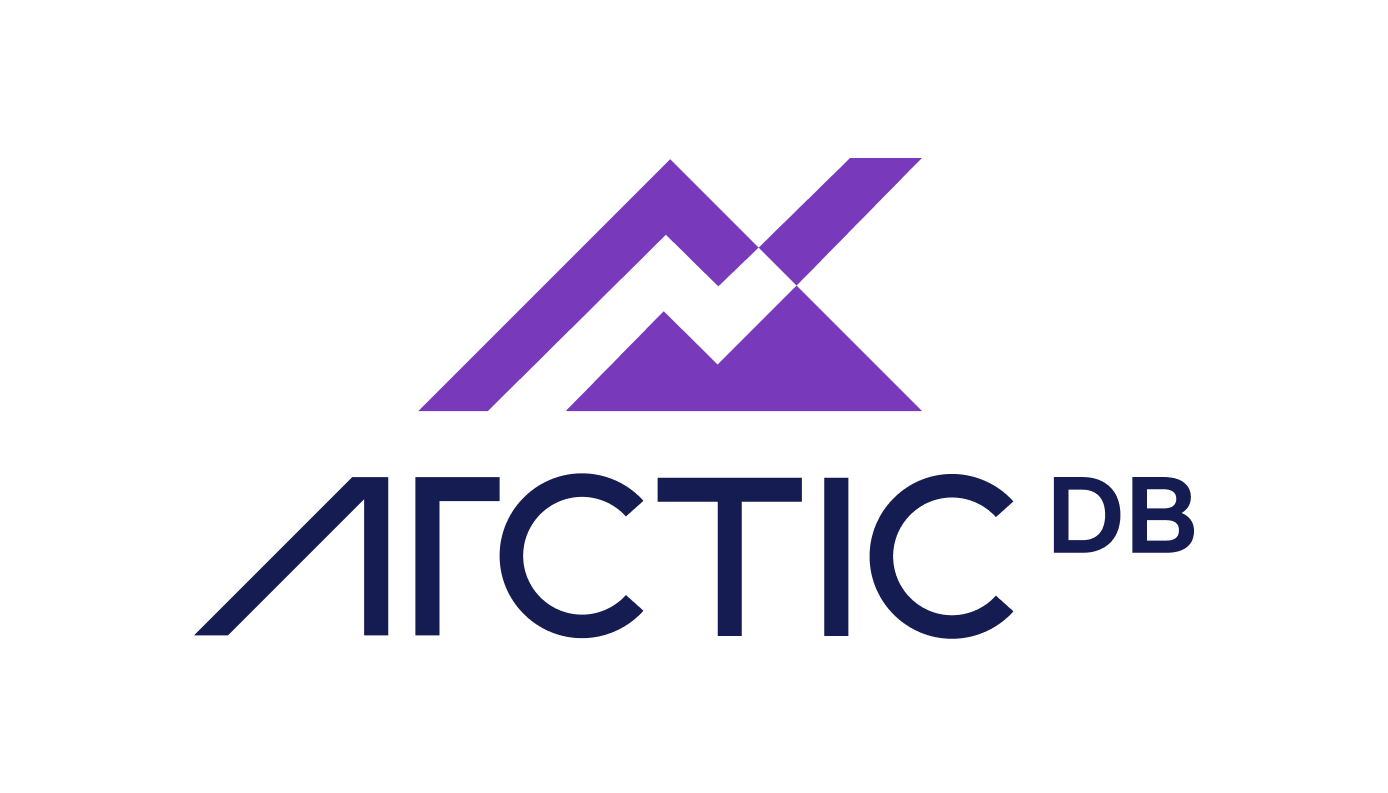
</center>

# ArcticDB Data Compaction Demo

This demo notebook demonstrates the `compact_data` method for reslicing data on disk in order to optimise read performance, and the accompanying `compact_data_explain_plan` method.

This is what you need to know about it:
* After running `compact_data` against a symbol, all chunks on disk are guaranteed to have a row-count within 33% of some target value.
    * This target value defaults to the `rows_per_segment` library config setting if not specified.
* The compaction operates on the latest live version of the symbol, and creates a new version unless the data is already suitably compacted.
* The metadata from the latest live version is maintained by the `compact_data` method.
* `compact_data_explain_plan` is like a dry run of the compaction, showing what the effect of running `compact_data` would be. No actual data is read from or written to disk.

For more information about the on-disk data format, see [this section](https://docs.arcticdb.io/latest/technical/on_disk_storage/) of the documentation, as well as the [documentation](https://docs.arcticdb.io/latest/api/arctic/#arcticdb.LibraryOptions) for the `rows_per_segment` library configuration option.

## Setup

In [ ]:
!pip install arcticdb

In [2]:
# To ensure reproducible performance measurements
import os
os.environ["ARCTICDB_VersionStore_NumCPUThreads_int"] = "4"

In [3]:
import numpy as np
import pandas as pd
import arcticdb as adb

In [4]:
rng = np.random.default_rng()

In [5]:
# object store
arctic = adb.Arctic("lmdb://arcticdb_compact_data")

In [6]:
# So that each run of the notebook starts from an empty library
arctic.delete_library("compact_data")
# library - rows_per_segment not specified, so will default to 100,000
lib = arctic.get_library("compact_data", create_if_missing=True)
# symbol
sym = "OHLCV_minutely"

## Create Some Data

* Simulate open-high-low-close-volume (OHLCV) minutely data since the turn of the millennium
* Writing pattern is to append one day's worth of data at a time
* This will create 1 data key for each call to append

In [7]:
days = pd.date_range("2000-01-01", "2026-01-01", freq="B")
len(days)

6784

In [8]:
def generate_day_data(day):
    minutely_ts = pd.date_range(day + pd.Timedelta(hours=8), day + pd.Timedelta(hours=16), freq="min")
    num_rows = len(minutely_ts)
    return pd.DataFrame({"open": rng.random(num_rows), "high": rng.random(num_rows), "low": rng.random(num_rows), "close": rng.random(num_rows), "volume": rng.random(num_rows)}, index=minutely_ts)

In [9]:
for day in days:
    df = generate_day_data(day)
    lib.append(sym, df, metadata=f"some metadata {day}")

### This reads 6,784 data keys:

In [10]:
%%timeit
lib.read(sym)

45.7 ms ± 1.72 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
vit_before_compaction = lib.read(sym)
vit_before_compaction.data

,open,high,low,close,volume
2000-01-03 08:00:00,0.652239,0.559158,0.377035,0.262168,0.988915
2000-01-03 08:01:00,0.519549,0.814606,0.754541,0.258416,0.147980
2000-01-03 08:02:00,0.261307,0.525803,0.486785,0.956356,0.771978
2000-01-03 08:03:00,0.186911,0.061975,0.462259,0.481657,0.419798
2000-01-03 08:04:00,0.931898,0.025461,0.715260,0.205572,0.600472
...,...,...,...,...,...
2026-01-01 15:56:00,0.017824,0.529770,0.020662,0.079490,0.902616
2026-01-01 15:57:00,0.986598,0.380662,0.423765,0.822334,0.373985
2026-01-01 15:58:00,0.083624,0.424631,0.749354,0.270700,0.977522
2026-01-01 15:59:00,0.642927,0.110095,0.376601,0.399092,0.289307


In [12]:
vit_before_compaction.version

6783

In [13]:
vit_before_compaction.metadata

'some metadata 2026-01-01 00:00:00'

## Find out what impact calling `compact_data` would have

In [14]:
compact_data_info = lib.compact_data_explain_plan(sym)
compact_data_info

CompactDataInfo(will_do_work=true, version_id_before=6783, version_id_after=6784, num_row_slices_before=6784, num_row_slices_after=33)

* `will_do_work` - whether calling `compact_data` will do any compaction, or do nothing if the data is already suitably compacted
* `version_id_before` - the version number of the latest live version right now
* `version_id_after` - the version number of the latest version after calling `compact_data`
* `num_row_slices_before` - how many row-slices the data is comprised of right now
* `num_row_slices_after` - how many row-slices the data will have after calling `compact_data`

In addition to the fields shown in the string representation above, there are also lists that show the row-slice boundaries before and after compaction.

Before compaction, every row slice has 481 rows:

In [15]:
compact_data_info.row_slices_before[:5]

[0, 481, 962, 1443, 1924]

In [16]:
compact_data_info.row_slices_before[-5:]

[3261180, 3261661, 3262142, 3262623, 3263104]

### After compaction, every row-slice will have 100,000 ±33% rows. This is because we did not specify the `rows_per_segment` argument, and so it used the library default of 100,000:

In [17]:
compact_data_info.row_slices_after

[0,
 100048,
 200096,
 300144,
 400192,
 500240,
 600288,
 700336,
 800384,
 900432,
 1000480,
 1100528,
 1200576,
 1300624,
 1400672,
 1500720,
 1600768,
 1700816,
 1800864,
 1900912,
 2000960,
 2101008,
 2201056,
 2301104,
 2401152,
 2501200,
 2601248,
 2701296,
 2801344,
 2901392,
 3001440,
 3101488,
 3182296,
 3263104]

### Print the number of rows in each slice after compaction:

In [18]:
for idx in range(len(compact_data_info.row_slices_after) - 1):
    print(compact_data_info.row_slices_after[idx + 1] - compact_data_info.row_slices_after[idx])

100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
100048
80808
80808


### Note that the row-slices do not all have the same number of rows post-compaction. The reasoning for this will be explained below.

# Compact the data!

In [19]:
lib.compact_data(sym)

VersionedItem(symbol='OHLCV_minutely', library='compact_data', data=n/a, version=6784, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1779456252894183043)

### Like other modification operations, this returns a `VersionedItem` containing information about the version that was just written

### The data is unchanged, but now only 33 (larger) data keys need to be read. This is of particular benefit on higher latency storages where bandwidth isn't an issue, but each IO round trip adds 10s or 100s of milliseconds

In [20]:
%%timeit
lib.read(sym)

13.8 ms ± 1.16 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Even on LMDB storage with zero latency, runs ~x3.5 faster!

In [21]:
vit_after_compaction = lib.read(sym)
vit_after_compaction.data

,open,high,low,close,volume
2000-01-03 08:00:00,0.652239,0.559158,0.377035,0.262168,0.988915
2000-01-03 08:01:00,0.519549,0.814606,0.754541,0.258416,0.147980
2000-01-03 08:02:00,0.261307,0.525803,0.486785,0.956356,0.771978
2000-01-03 08:03:00,0.186911,0.061975,0.462259,0.481657,0.419798
2000-01-03 08:04:00,0.931898,0.025461,0.715260,0.205572,0.600472
...,...,...,...,...,...
2026-01-01 15:56:00,0.017824,0.529770,0.020662,0.079490,0.902616
2026-01-01 15:57:00,0.986598,0.380662,0.423765,0.822334,0.373985
2026-01-01 15:58:00,0.083624,0.424631,0.749354,0.270700,0.977522
2026-01-01 15:59:00,0.642927,0.110095,0.376601,0.399092,0.289307


In [22]:
vit_before_compaction.data.equals(vit_after_compaction.data)

True

### A new version has been created:

In [23]:
vit_after_compaction.version

6784

### The metadata is the same as the version that got compacted:

In [24]:
vit_after_compaction.metadata

'some metadata 2026-01-01 00:00:00'

# Now suppose a data vendor restates a single days worth of data:

In [25]:
day = days[1_000]
df = generate_day_data(day)
lib.update(sym, df)
df

,open,high,low,close,volume
2003-11-03 08:00:00,0.513891,0.731586,0.751961,0.947970,0.239459
2003-11-03 08:01:00,0.103845,0.013911,0.083932,0.264079,0.696063
2003-11-03 08:02:00,0.584501,0.905620,0.505111,0.143124,0.299208
2003-11-03 08:03:00,0.186388,0.188366,0.507724,0.299007,0.311037
2003-11-03 08:04:00,0.343084,0.009887,0.172661,0.187550,0.848564
...,...,...,...,...,...
2003-11-03 15:56:00,0.809524,0.905820,0.006144,0.731492,0.103905
2003-11-03 15:57:00,0.503292,0.884031,0.742494,0.414768,0.739807
2003-11-03 15:58:00,0.018958,0.534203,0.526111,0.062234,0.926631
2003-11-03 15:59:00,0.533881,0.098154,0.498576,0.255710,0.667218


In [26]:
compact_data_info = lib.compact_data_explain_plan(sym)
compact_data_info

CompactDataInfo(will_do_work=true, version_id_before=6785, version_id_after=6786, num_row_slices_before=35, num_row_slices_after=33)

In [27]:
compact_data_info.row_slices_before[4:8]

[400192, 481000, 481481, 500240]

In [28]:
compact_data_info.row_slices_after[4:6]

[400192, 500240]

## The 3 row-slices spanning rows 400,192 to 500,240 will be combined into 1
These cover the timestamps from `2003-03-12` to `2003-12-26` i.e. the date that was restated, plus some surrounding dates.

No other row-slices in the data will be compacted, as they are already suitably sized, and therefore do not need to be read, processed, and rewritten. This is why compaction does not necessarily produce uniform numbers of rows in each slice, as this can result in small appends or updates triggering all of the data to be rewritten during the compaction.

In [29]:
lib.compact_data(sym)

VersionedItem(symbol='OHLCV_minutely', library='compact_data', data=n/a, version=6786, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1779456264058020828)

## The data has just been compacted, and so compacting again immediately will have no effect:

In [30]:
lib.compact_data_explain_plan(sym)

CompactDataInfo(will_do_work=false, version_id_before=6786, version_id_after=6786, num_row_slices_before=33, num_row_slices_after=33)

## If the library default `rows_per_segment` is not appropriate for a symbol, this can be explicitly specified to both methods

In [31]:
lib.compact_data_explain_plan(sym, rows_per_segment=1_000_000)

CompactDataInfo(will_do_work=true, version_id_before=6786, version_id_after=6787, num_row_slices_before=33, num_row_slices_after=3)

In [32]:
lib.compact_data(sym, rows_per_segment=1_000_000)

VersionedItem(symbol='OHLCV_minutely', library='compact_data', data=n/a, version=6787, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1779456264292791517)

### This can also be used to slice into smaller segments if this aids read performance

In [33]:
lib.compact_data_explain_plan(sym, rows_per_segment=10_000)

CompactDataInfo(will_do_work=true, version_id_before=6787, version_id_after=6788, num_row_slices_before=3, num_row_slices_after=247)

In [34]:
lib.compact_data(sym, rows_per_segment=10_000)

VersionedItem(symbol='OHLCV_minutely', library='compact_data', data=n/a, version=6788, metadata=None, host='LMDB(path=/users/is/aowens/source/man.arcticdb/arcticdb_link/docs/mkdocs/docs/notebooks/arcticdb_compact_data)', timestamp=1779456264576206308)